# MarketLens Stage 3: Clean and Merge Data

This notebook cleans and merges the raw SPY market data with the DGS10 10-Year Treasury yield data.

Inputs:
- `data/raw/spy_prices.csv`
- `data/raw/dgs10_yield.csv`

Output:
- `data/processed/marketlens_dataset.csv`

#### Imports and project root

In [2]:
from pathlib import Path
import os
import pandas as pd

PROJECT_ROOT = Path(r"C:\Users\Wilson\Documents\OpenAI\MarketLens")
os.chdir(PROJECT_ROOT)

RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
REPORTS_DIR = PROJECT_ROOT / "reports"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print("Current working directory:")
print(Path.cwd())

print("\nRaw data folder:")
print(RAW_DIR)

print("\nProcessed data folder:")
print(PROCESSED_DIR)

Current working directory:
C:\Users\Wilson\Documents\OpenAI\MarketLens

Raw data folder:
C:\Users\Wilson\Documents\OpenAI\MarketLens\data\raw

Processed data folder:
C:\Users\Wilson\Documents\OpenAI\MarketLens\data\processed


#### Load raw data

In [4]:
spy_path = RAW_DIR / "spy_prices.csv"
dgs10_path = RAW_DIR / "dgs10_yield.csv"

if not spy_path.exists():
    raise FileNotFoundError(f"Missing file: {spy_path}")

if not dgs10_path.exists():
    raise FileNotFoundError(f"Missing file: {dgs10_path}")

spy = pd.read_csv(spy_path)
dgs10 = pd.read_csv(dgs10_path)

print("SPY shape:", spy.shape)
print("DGS10 shape:", dgs10.shape)

display(spy.head())
display(dgs10.head())

SPY shape: (2136, 7)
DGS10 shape: (2218, 2)


,date,open,high,low,close,adj_close,volume
0,2018-01-02,267.839996,268.809998,267.399994,268.769989,235.954208,86655700
1,2018-01-03,268.959991,270.640015,268.959991,270.470001,237.446716,90070400
2,2018-01-04,271.200012,272.160004,270.540009,271.609985,238.447495,80636400
3,2018-01-05,272.510010,273.559998,271.950012,273.420013,240.036560,83524000
4,2018-01-08,273.309998,274.100006,272.980011,273.920013,240.475525,57319200


,date,dgs10
0,2018-01-01,NaN
1,2018-01-02,2.46
2,2018-01-03,2.44
3,2018-01-04,2.46
4,2018-01-05,2.47


#### Inspect columns

In [5]:
print("SPY columns:")
print(spy.columns.tolist())

print("\nDGS10 columns:")
print(dgs10.columns.tolist())

print("\nSPY data types:")
print(spy.dtypes)

print("\nDGS10 data types:")
print(dgs10.dtypes)

SPY columns:
['date', 'open', 'high', 'low', 'close', 'adj_close', 'volume']

DGS10 columns:
['date', 'dgs10']

SPY data types:
date             str
open         float64
high         float64
low          float64
close        float64
adj_close    float64
volume         int64
dtype: object

DGS10 data types:
date         str
dgs10    float64
dtype: object


#### Clean SPY data

In [6]:
spy_clean = spy.copy()

# Standardize column names again for safety
spy_clean.columns = [str(col).lower().replace(" ", "_") for col in spy_clean.columns]

# Convert date column
spy_clean["date"] = pd.to_datetime(spy_clean["date"], errors="coerce")

# Remove rows with invalid dates
spy_clean = spy_clean.dropna(subset=["date"])

# Sort by date
spy_clean = spy_clean.sort_values("date").reset_index(drop=True)

# Convert numeric columns
numeric_cols = ["open", "high", "low", "close", "adj_close", "volume"]

for col in numeric_cols:
    if col in spy_clean.columns:
        spy_clean[col] = pd.to_numeric(spy_clean[col], errors="coerce")

# Keep only useful columns
keep_cols = [col for col in ["date", "open", "high", "low", "close", "adj_close", "volume"] if col in spy_clean.columns]
spy_clean = spy_clean[keep_cols]

print("Cleaned SPY shape:", spy_clean.shape)
display(spy_clean.head())
display(spy_clean.tail())

Cleaned SPY shape: (2136, 7)


,date,open,high,low,close,adj_close,volume
0,2018-01-02,267.839996,268.809998,267.399994,268.769989,235.954208,86655700
1,2018-01-03,268.959991,270.640015,268.959991,270.470001,237.446716,90070400
2,2018-01-04,271.200012,272.160004,270.540009,271.609985,238.447495,80636400
3,2018-01-05,272.510010,273.559998,271.950012,273.420013,240.036560,83524000
4,2018-01-08,273.309998,274.100006,272.980011,273.920013,240.475525,57319200


,date,open,high,low,close,adj_close,volume
2131,2026-06-26,728.950012,736.530029,716.580017,728.989990,728.989990,71034000
2132,2026-06-29,736.530029,741.559998,732.090027,741.000000,741.000000,58035200
2133,2026-06-30,741.289978,748.020020,740.890015,746.770020,746.770020,55626000
2134,2026-07-01,745.000000,749.440002,742.380005,745.760010,745.760010,47100900
2135,2026-07-02,747.400024,751.309998,740.030029,744.780029,744.780029,57447800


#### Clean DGS10 data

In [7]:
dgs10_clean = dgs10.copy()

# Standardize column names
dgs10_clean.columns = [str(col).lower().replace(" ", "_") for col in dgs10_clean.columns]

# Convert date and value columns
dgs10_clean["date"] = pd.to_datetime(dgs10_clean["date"], errors="coerce")
dgs10_clean["dgs10"] = pd.to_numeric(dgs10_clean["dgs10"], errors="coerce")

# Remove invalid dates
dgs10_clean = dgs10_clean.dropna(subset=["date"])

# Sort by date
dgs10_clean = dgs10_clean.sort_values("date").reset_index(drop=True)

print("Cleaned DGS10 shape:", dgs10_clean.shape)
display(dgs10_clean.head())
display(dgs10_clean.tail())

Cleaned DGS10 shape: (2218, 2)


,date,dgs10
0,2018-01-01,NaN
1,2018-01-02,2.46
2,2018-01-03,2.44
3,2018-01-04,2.46
4,2018-01-05,2.47


,date,dgs10
2213,2026-06-25,4.40
2214,2026-06-26,4.38
2215,2026-06-29,4.38
2216,2026-06-30,4.44
2217,2026-07-01,4.48


#### Merge SPY and DGS10

In [8]:
marketlens = pd.merge(
    spy_clean,
    dgs10_clean,
    on="date",
    how="left"
)

# Fill missing DGS10 values forward
marketlens["dgs10"] = marketlens["dgs10"].ffill()

# Remove rows where key market columns are missing
marketlens = marketlens.dropna(subset=["close"])

# Sort and reset index
marketlens = marketlens.sort_values("date").reset_index(drop=True)

print("Merged dataset shape:", marketlens.shape)
display(marketlens.head())
display(marketlens.tail())

Merged dataset shape: (2136, 8)


,date,open,high,low,close,adj_close,volume,dgs10
0,2018-01-02,267.839996,268.809998,267.399994,268.769989,235.954208,86655700,2.46
1,2018-01-03,268.959991,270.640015,268.959991,270.470001,237.446716,90070400,2.44
2,2018-01-04,271.200012,272.160004,270.540009,271.609985,238.447495,80636400,2.46
3,2018-01-05,272.510010,273.559998,271.950012,273.420013,240.036560,83524000,2.47
4,2018-01-08,273.309998,274.100006,272.980011,273.920013,240.475525,57319200,2.49


,date,open,high,low,close,adj_close,volume,dgs10
2131,2026-06-26,728.950012,736.530029,716.580017,728.989990,728.989990,71034000,4.38
2132,2026-06-29,736.530029,741.559998,732.090027,741.000000,741.000000,58035200,4.38
2133,2026-06-30,741.289978,748.020020,740.890015,746.770020,746.770020,55626000,4.44
2134,2026-07-01,745.000000,749.440002,742.380005,745.760010,745.760010,47100900,4.48
2135,2026-07-02,747.400024,751.309998,740.030029,744.780029,744.780029,57447800,4.48


#### Check missing values

In [9]:
missing_summary = marketlens.isna().sum().to_frame(name="missing_values")
missing_summary["missing_percent"] = (missing_summary["missing_values"] / len(marketlens) * 100).round(2)

display(missing_summary)

,missing_values,missing_percent
date,0,0.0
open,0,0.0
high,0,0.0
low,0,0.0
close,0,0.0
adj_close,0,0.0
volume,0,0.0
dgs10,0,0.0


#### Check duplicate dates

In [10]:
duplicate_dates = marketlens["date"].duplicated().sum()

print("Duplicate dates:", duplicate_dates)

if duplicate_dates > 0:
    marketlens = marketlens.drop_duplicates(subset=["date"], keep="last")
    print("Duplicates removed.")
    print("New shape:", marketlens.shape)

Duplicate dates: 0


#### Save processed dataset

In [11]:
processed_path = PROCESSED_DIR / "marketlens_dataset.csv"

marketlens.to_csv(processed_path, index=False)

print(f"Processed dataset saved to: {processed_path}")
print(f"Rows: {len(marketlens)}")
print(f"Columns: {marketlens.columns.tolist()}")

Processed dataset saved to: C:\Users\Wilson\Documents\OpenAI\MarketLens\data\processed\marketlens_dataset.csv
Rows: 2136
Columns: ['date', 'open', 'high', 'low', 'close', 'adj_close', 'volume', 'dgs10']


#### Reload and verify saved dataset

In [12]:
saved_check = pd.read_csv(processed_path)

print("Saved dataset shape:", saved_check.shape)
print("Saved dataset columns:")
print(saved_check.columns.tolist())

display(saved_check.head())

Saved dataset shape: (2136, 8)
Saved dataset columns:
['date', 'open', 'high', 'low', 'close', 'adj_close', 'volume', 'dgs10']


,date,open,high,low,close,adj_close,volume,dgs10
0,2018-01-02,267.839996,268.809998,267.399994,268.769989,235.954208,86655700,2.46
1,2018-01-03,268.959991,270.640015,268.959991,270.470001,237.446716,90070400,2.44
2,2018-01-04,271.200012,272.160004,270.540009,271.609985,238.447495,80636400,2.46
3,2018-01-05,272.510010,273.559998,271.950012,273.420013,240.036560,83524000,2.47
4,2018-01-08,273.309998,274.100006,272.980011,273.920013,240.475525,57319200,2.49


#### Quick visual check

Text(0, 0.5, 'SPY Close Price')

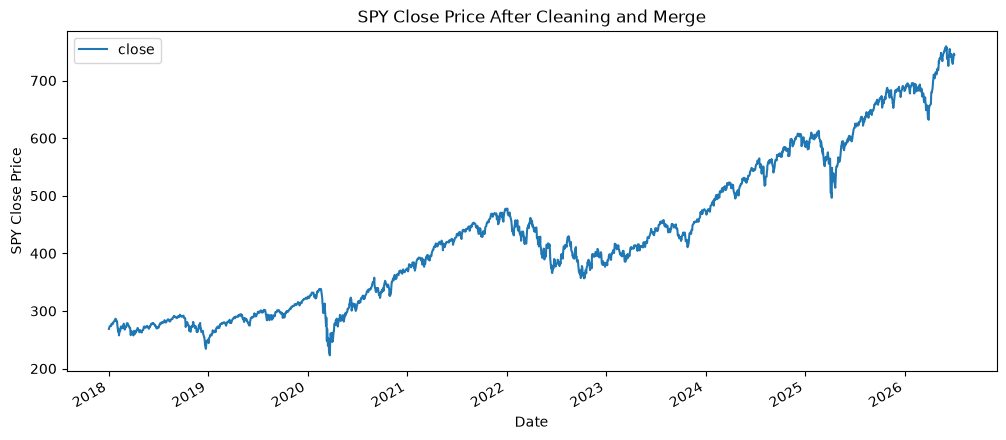

In [14]:
plot_data = saved_check.copy()
plot_data["date"] = pd.to_datetime(plot_data["date"])

ax = plot_data.plot(
    x="date",
    y="close",
    figsize=(12, 5),
    title="SPY Close Price After Cleaning and Merge"
)

ax.set_xlabel("Date")
ax.set_ylabel("SPY Close Price")

#### Save clean-merge report

In [15]:
from datetime import datetime

report_path = REPORTS_DIR / "clean_merge_check.txt"

report = f"""
MarketLens Clean and Merge Check

Status: Clean and merge completed.
Timestamp: {datetime.now()}

Input files:
- data/raw/spy_prices.csv
- data/raw/dgs10_yield.csv

Output file:
- data/processed/marketlens_dataset.csv

Rows in final dataset: {len(marketlens)}
Columns in final dataset: {marketlens.columns.tolist()}

Date range:
- Start date: {marketlens["date"].min()}
- End date: {marketlens["date"].max()}

Missing values:
{marketlens.isna().sum().to_string()}

Duplicate dates: {marketlens["date"].duplicated().sum()}

Note:
This dataset is for educational and portfolio demonstration only. It does not prove that any trading or investment strategy is profitable.
"""

report_path.write_text(report.strip(), encoding="utf-8")

print(f"Report saved to: {report_path}")

Report saved to: C:\Users\Wilson\Documents\OpenAI\MarketLens\reports\clean_merge_check.txt
